In [53]:
import sys
from pathlib import Path

# Path to the parent folder (where util is)
parent_path = Path().resolve().parent.parent
sys.path.append(str(parent_path))
import util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import help_functions as hp
import tueplots as tue

data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\final_data_iaaf_scores_neu.csv') 

data.head()

data_ext = data

top_raw_all = hp.collect_top_entries(data, num_entries=30)

In [2]:
# Exclude outliers that are not explainable

data = data[(data["iaaf_score"] < 1380) & (data["iaaf_score"] > 20)]

# Define Discipline groups NOTE: Only the ones with clear data

run_disciplines = ['800 m', '1500 m', '3000 m']
sprint_disciplines = ['100 m', '200 m', '400 m', '400m Huerden']
throw_disciplines = ['Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf']
jump_disciplines = ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']

# Combine all into a single list
all_disciplines = run_disciplines + sprint_disciplines + jump_disciplines + throw_disciplines 

data = data[data["disziplin"].isin(all_disciplines)]

#data = data[(data["altersklasse"] == "Frauen")|( data["altersklasse"] == "Maenner")]

In [3]:
top_n = 40
top_raw = hp.collect_top_entries(data, num_entries=top_n)

In [4]:
# Parameters
ranks = range(1, top_n + 1)

# Age mapping
age_map = {"18": "18", "20": "20", "U23": "U23", "Maenner": "Adult", "Frauen": "Adult"}

# Store all results
results_list = []

# Unique events and genders
events = data["disziplin"].unique()
genders = ["M", "W"]
age_groups = ["18", "20", "U23", "Adult"]

for event in events:
    for gender in genders:
        for age in age_groups:
            # Filter subgroup
            subdata = data[
                (data["disziplin"] == event) &
                (data["geschlecht"] == gender) &
                (data["altersklasse"].map(age_map) == age)
            ]
            if subdata.empty:
                continue

            # Collect top entries
            top_raw = hp.collect_top_entries(subdata, num_entries=top_n)

            # Group by sub-subgroups (discipline/gender/age), usually only one here
            for (disc, g, a), subgroup in top_raw.groupby(["disziplin","geschlecht","altersklasse"]):
                # Scores per year, top ranks
                S_g = subgroup.groupby("jahr")["iaaf_score"].apply(
                    lambda x: x.sort_values(ascending=False).head(top_n).values
                )
                if 2001 not in S_g.index:
                    continue  # skip subgroups without baseline

                # Build DataFrame: years × ranks
                S_gr = pd.DataFrame({year: vals for year, vals in zip(S_g.index, S_g.values)}).T
                S_gr.columns = range(1, top_n+1)
                S_gr.index.name = "jahr"

                # Compute mean score per rank per period
                start_avg = S_gr.loc[2001:2004].mean()
                end_avg   = S_gr.loc[2021:2024].mean()
                start_std = S_gr.loc[2001:2004].values.flatten().std()
                end_std   = S_gr.loc[2021:2024].values.flatten().std()
         
                # Percent change per rank
                diff_avg = (end_avg - start_avg) / start_avg * 100

                diff_std = (end_std - start_std) / start_std * 100

                # Append results in long format
                for r in ranks:
                    results_list.append({
                        "event": event,
                        "gender": gender,
                        "age": age,
                        "rank": r,
                        "diff": diff_avg[r],
                        "start_avg": start_avg[r],
                        "end_avg": end_avg[r],
                        "diff_std": diff_std,
                        "start_std": start_std,
                        "end_std": end_std
                    })

# Convert to DataFrame
results_df = pd.DataFrame(results_list)

c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Lite

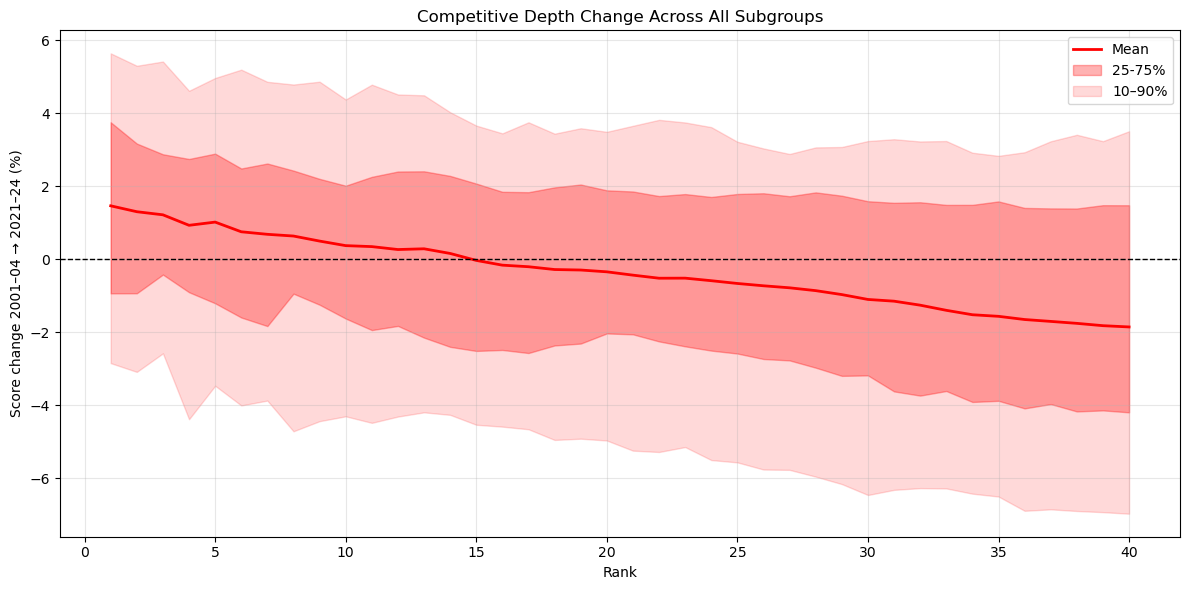

In [31]:

results_df['subgroup'] = results_df['event'] + "_" + results_df['gender'] + "_" + results_df['age']

# Pivot to wide format: rows=subgroups, columns=ranks
diff_df = results_df.pivot(index='subgroup', columns='rank', values='diff')

# Sort ranks just in case
diff_df = diff_df.sort_index(axis=1)

# Compute mean and quantiles per rank
mean_diff = diff_df.mean(axis=0)
q10 = diff_df.quantile(0.10)
q25 = diff_df.quantile(0.25)
q75 = diff_df.quantile(0.75)
q90 = diff_df.quantile(0.90)

# Plot
plt.figure(figsize=(12,6))

# Mean line
plt.plot(diff_df.columns, mean_diff, color="red", linewidth=2, label="Mean")

# Shaded IQR (25–75%)
plt.fill_between(diff_df.columns, q25, q75, color="red", alpha=0.3, label="25-75%")

# Shaded 10–90%
plt.fill_between(diff_df.columns, q10, q90, color="red", alpha=0.15, label="10–90%")

# Reference line at 0
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Rank")
plt.ylabel("Score change 2001–04 → 2021–24 (%)")
plt.title("Competitive Depth Change Across All Subgroups")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


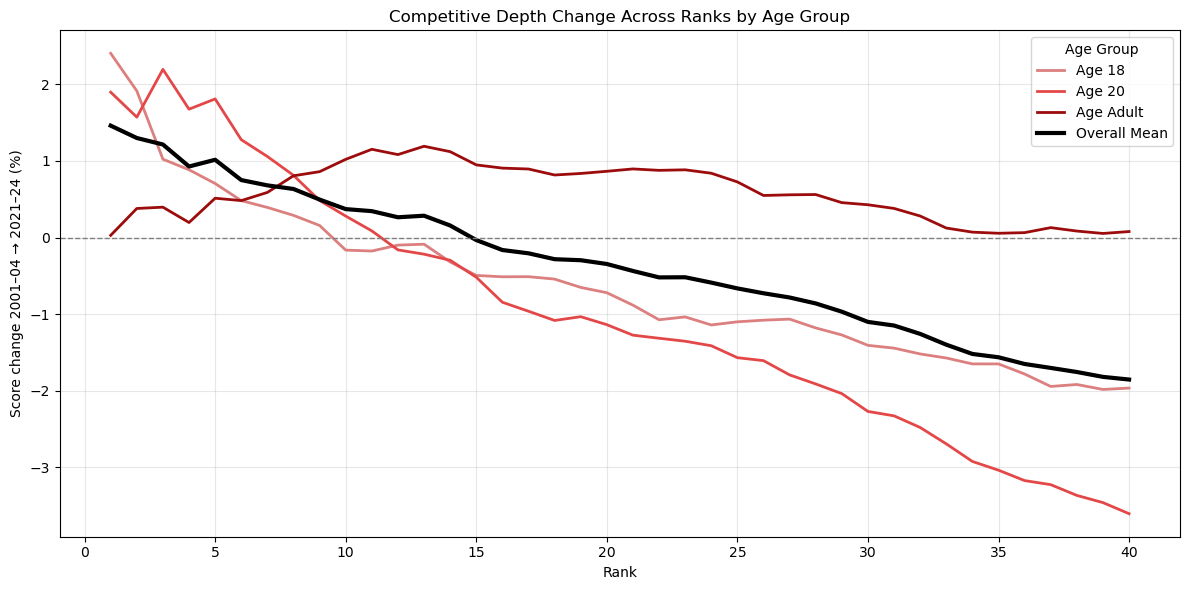

In [22]:
import matplotlib.pyplot as plt

# Define colors for age groups
age_colors = {"18": "#DC7F7F", "20": "#E44747", "U23": "#D61616", "Adult": "#9c0c0c"}

plt.figure(figsize=(12,6))

# Plot mean per age group
for age in results_df['age'].unique():
    df_age = results_df[results_df['age'] == age].copy()
    
    diff_df = df_age.pivot(index='subgroup', columns='rank', values='diff').sort_index(axis=1)
    
    # Mean line per age group
    mean_diff = diff_df.mean(axis=0)
    plt.plot(diff_df.columns, mean_diff, color=age_colors[age], linewidth=2, label=f"Age {age}")

# Plot overall mean line across all subgroups
diff_df_all = results_df.pivot(index='subgroup', columns='rank', values='diff').sort_index(axis=1)
overall_mean = diff_df_all.mean(axis=0)
plt.plot(diff_df_all.columns, overall_mean, color="black", linewidth=3, label="Overall Mean")

# Reference line at 0
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Rank")
plt.ylabel("Score change 2001–04 → 2021–24 (%)")
plt.title("Competitive Depth Change Across Ranks by Age Group")
plt.legend(title="Age Group")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [41]:
print(f"Overall difference change of rank 1 to 40: {(overall_mean[1]-overall_mean[40]): .2f} %")
for age in results_df['age'].unique():
    df_age = results_df[results_df['age'] == age].copy()
    
    diff_df = df_age.pivot(index='subgroup', columns='rank', values='diff').sort_index(axis=1)
    
    # Mean line per age group
    mean_diff = diff_df.mean(axis=0)
    print(f"{age} difference change of rank 1 to 40: {(mean_diff[1]-mean_diff[40]): .2f} %")
    print(f"{age} top 1 change: {mean_diff[1]: .2f} %; top 40 change: {mean_diff[40]: .2f} %")


Overall difference change of rank 1 to 40:  3.32 %
18 difference change of rank 1 to 40:  4.37 %
18 top 1 change:  2.41 %; top 40 change: -1.97 %
20 difference change of rank 1 to 40:  5.51 %
20 top 1 change:  1.90 %; top 40 change: -3.61 %
Adult difference change of rank 1 to 40: -0.05 %
Adult top 1 change:  0.03 %; top 40 change:  0.08 %


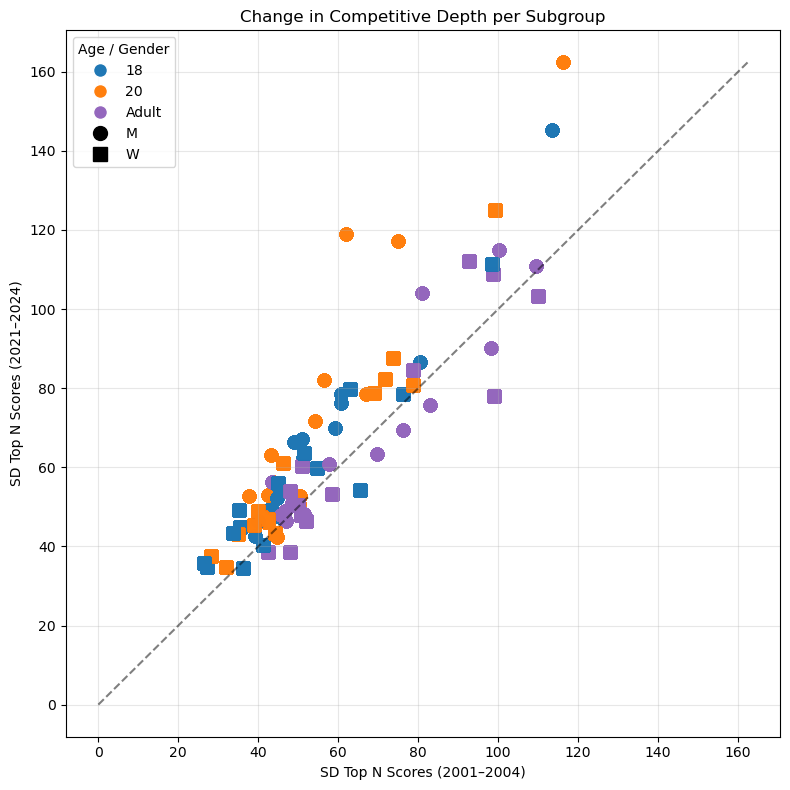

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(8,8))

# Define colors for age groups
age_colors = {"18": "#1f77b4", "20": "#ff7f0e", "Adult": "#9467bd"}

# Define markers for gender
gender_markers = {'M': 'o', 'W': 's'}

# Plot points
for i, row in results_df.iterrows():
    plt.scatter(row['start_std'], row['end_std'],
                color=age_colors[row['age']],
                marker=gender_markers[row['gender']],
                s=80, alpha=0.7)

# Diagonal line
max_val = max(results_df['start_std'].max(), results_df['end_std'].max())
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5)

plt.xlabel("SD Top N Scores (2001–2004)")
plt.ylabel("SD Top N Scores (2021–2024)")
plt.title("Change in Competitive Depth per Subgroup")
plt.grid(True, alpha=0.3)

# Create custom legend
age_legend = [Line2D([0],[0], marker='o', color='w', label=age,
                     markerfacecolor=color, markersize=10) 
              for age, color in age_colors.items()]
gender_legend = [Line2D([0],[0], marker=marker, color='k', label=gender,
                        linestyle='None', markersize=10) 
                 for gender, marker in gender_markers.items()]

# Combine legends
plt.legend(handles=age_legend + gender_legend, title="Age / Gender", loc='upper left', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()


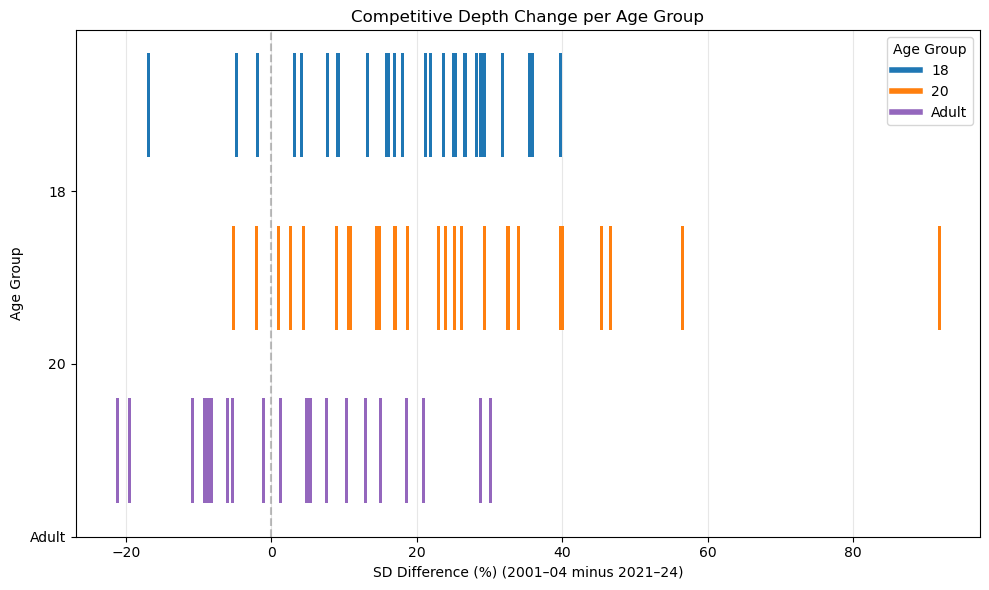

In [8]:
import matplotlib.pyplot as plt

# Only the age groups we want
age_groups = ["Adult", "20", "18"]
df_plot = results_df[results_df['age'].isin(age_groups)].copy()
age_colors = {"18": "#1f77b4", "20": "#ff7f0e", "Adult": "#9467bd"}

plt.figure(figsize=(10,6))

# Loop over age groups
for i, age in enumerate(age_groups):
    df_age = df_plot[df_plot['age'] == age]
    
    # Each subgroup = vertical line at std diff
    for _, row in df_age.iterrows():
        plt.vlines(x=row['diff_std'], ymin=i + 0.2, ymax=i + 0.8,
                   color=age_colors[age],
                   linewidth=2,
                   alpha=0.7)

# Y-axis labels
plt.yticks(range(len(age_groups)), age_groups)
plt.xlabel("SD Difference (%) (2001–04 minus 2021–24)")
plt.ylabel("Age Group")
plt.title("Competitive Depth Change per Age Group")
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3, axis='x')

# Legend for age groups
from matplotlib.lines import Line2D
age_legend = [Line2D([0],[0], color=color, lw=4, label=age) for age, color in age_colors.items()]
plt.legend(handles=age_legend, title="Age Group", loc='upper right')

plt.tight_layout()
plt.show()


In [18]:
from matplotlib.lines import Line2D


data_std = hp.func_norm_per_group(data=top_raw_all, func=np.std)

df_std = pd.DataFrame(data_std)

df_std['age'] = df_std['age'].replace({'Maenner': 'Adult', 'Frauen': 'Adult', '16': 'U16', '18': 'U18', '20': 'U20'})

df_start = df_std[df_std['year'].between(2001, 2004)].groupby(['event','gender','age'])['func_value'].mean().reset_index()
df_end   = df_std[df_std['year'].between(2021, 2024)].groupby(['event','gender','age'])['func_value'].mean().reset_index()

df_diff = pd.merge(df_start, df_end, on=['event','gender','age'], suffixes=('_start','_end'))
df_diff['std_diff'] = df_diff['func_value_end'] - df_diff['func_value_start']

unique_ages = sorted([a for a in df_diff['age'].unique() if a != 'Adult'], reverse=True)
age_order = ['Adult'] + unique_ages 
genders = ['M', 'W']
gender_colors = {'M': 'darkred', 'W': 'lightcoral'}

y_map = {}
y_labels = []
y_pos = 0

# Create a separate row for every Age + Gender combination
for age in age_order:
    for gender in genders:
        y_map[(age, gender)] = y_pos
        label = f"{age} - {'Men' if gender == 'M' else 'Women'}"
        y_labels.append(label)
        y_pos += 1



c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:75: FutureWarning: The provided callable <function std at 0x000001E8301B91C0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)


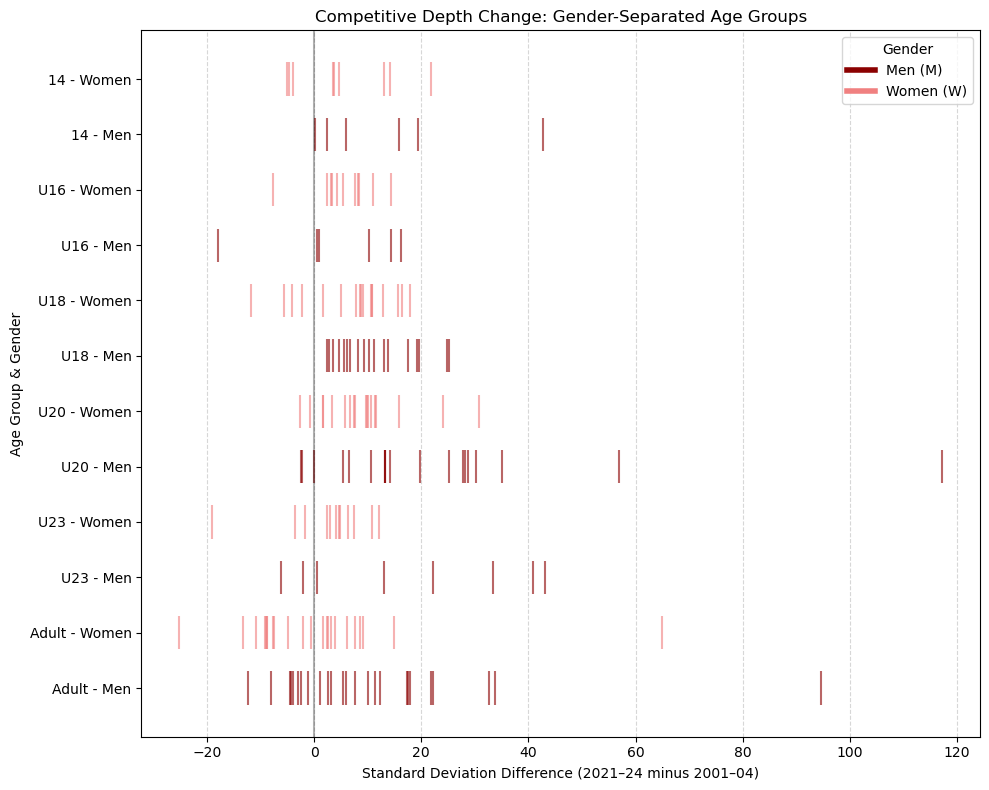

In [19]:
# 4. Plotting
plt.figure(figsize=(10, 8))

for _, row in df_diff.iterrows():
    # Find the specific Y coordinate for this age and gender
    y = y_map.get((row['age'], row['gender']))
    
    if y is not None:
        color = gender_colors[row['gender']]
        plt.vlines(x=row['std_diff'], ymin=y-0.3, ymax=y+0.3, 
                   color=color, alpha=0.6, linewidth=1.5)

# Formatting
plt.yticks(range(len(y_labels)), y_labels)
plt.axvline(0, color='black', linestyle='-', alpha=0.3)
plt.xlabel("Standard Deviation Difference (2021–24 minus 2001–04)")
plt.ylabel("Age Group & Gender")
plt.title("Competitive Depth Change: Gender-Separated Age Groups")

# Legend
legend_elements = [
    Line2D([0], [0], color='darkred', lw=4, label='Men (M)'),
    Line2D([0], [0], color='lightcoral', lw=4, label='Women (W)')
]
plt.legend(handles=legend_elements, title="Gender", loc='best')

plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

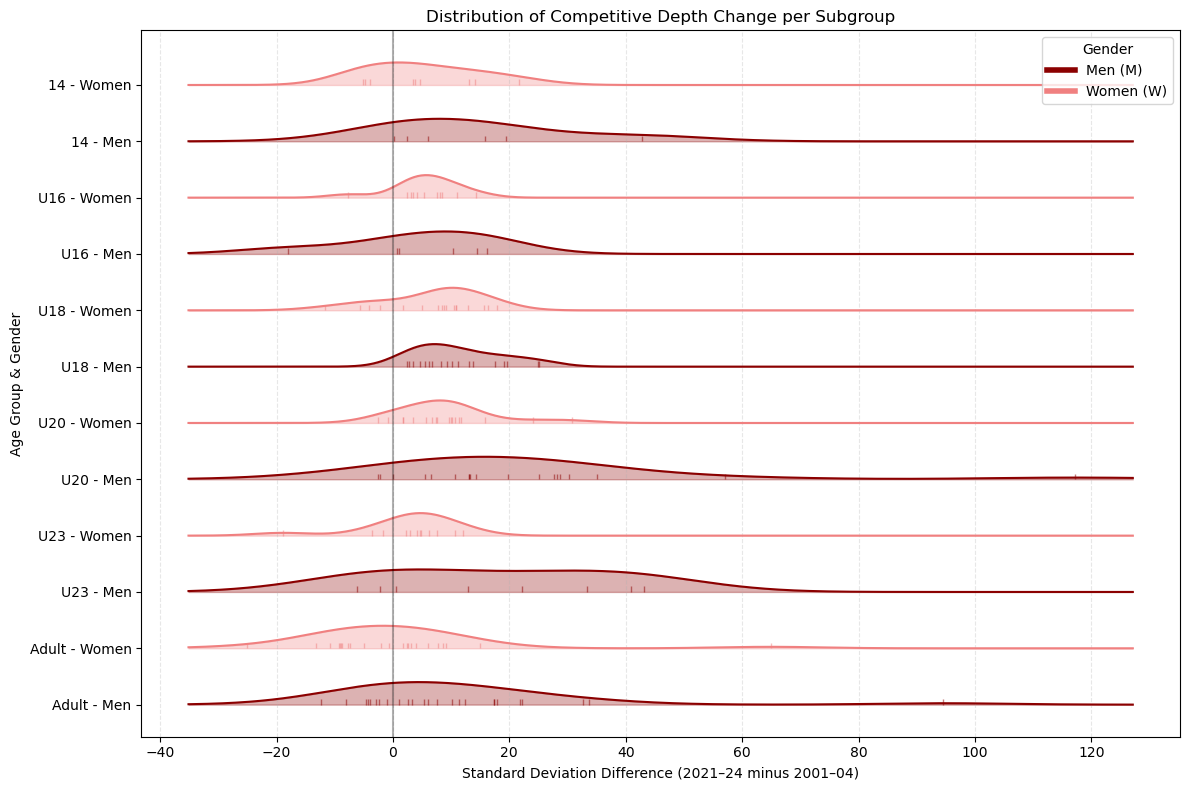

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

# ... (Previous data preparation code for df_diff and y_map remains the same) ...

plt.figure(figsize=(12, 8))

# Define the x-range for the curves
x_range = np.linspace(df_diff['std_diff'].min() - 10, df_diff['std_diff'].max() + 10, 500)

for (age, gender), y in y_map.items():
    # Filter data for this specific row
    subset = df_diff[(df_diff['age'] == age) & (df_diff['gender'] == gender)]['std_diff']
    
    if len(subset) > 1:  # Need at least two points for a distribution
        color = gender_colors[gender]
        
        # Calculate the density curve
        kde = gaussian_kde(subset)
        density = kde(x_range)
        
        # Normalize density so it fits within the row height (max height ~0.4)
        density_norm = (density / density.max()) * 0.4
        
        # Plot the curve
        plt.plot(x_range, density_norm + y, color=color, lw=1.5)
        
        # Fill the area under the curve
        plt.fill_between(x_range, y, density_norm + y, color=color, alpha=0.3)
        
        # Optional: Keep the "barcode" rug plot at the base of the curve
        plt.vlines(x=subset, ymin=y, ymax=y + 0.1, color=color, alpha=0.5, linewidth=1)

# Formatting
plt.yticks(range(len(y_labels)), y_labels)
plt.axvline(0, color='black', linestyle='-', alpha=0.3)
plt.xlabel("Standard Deviation Difference (2021–24 minus 2001–04)")
plt.ylabel("Age Group & Gender")
plt.title("Distribution of Competitive Depth Change per Subgroup")

# Updated Legend
legend_elements = [
    Line2D([0], [0], color='darkred', lw=4, label='Men (M)'),
    Line2D([0], [0], color='lightcoral', lw=4, label='Women (W)')
]
plt.legend(handles=legend_elements, title="Gender", loc='upper right')

plt.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

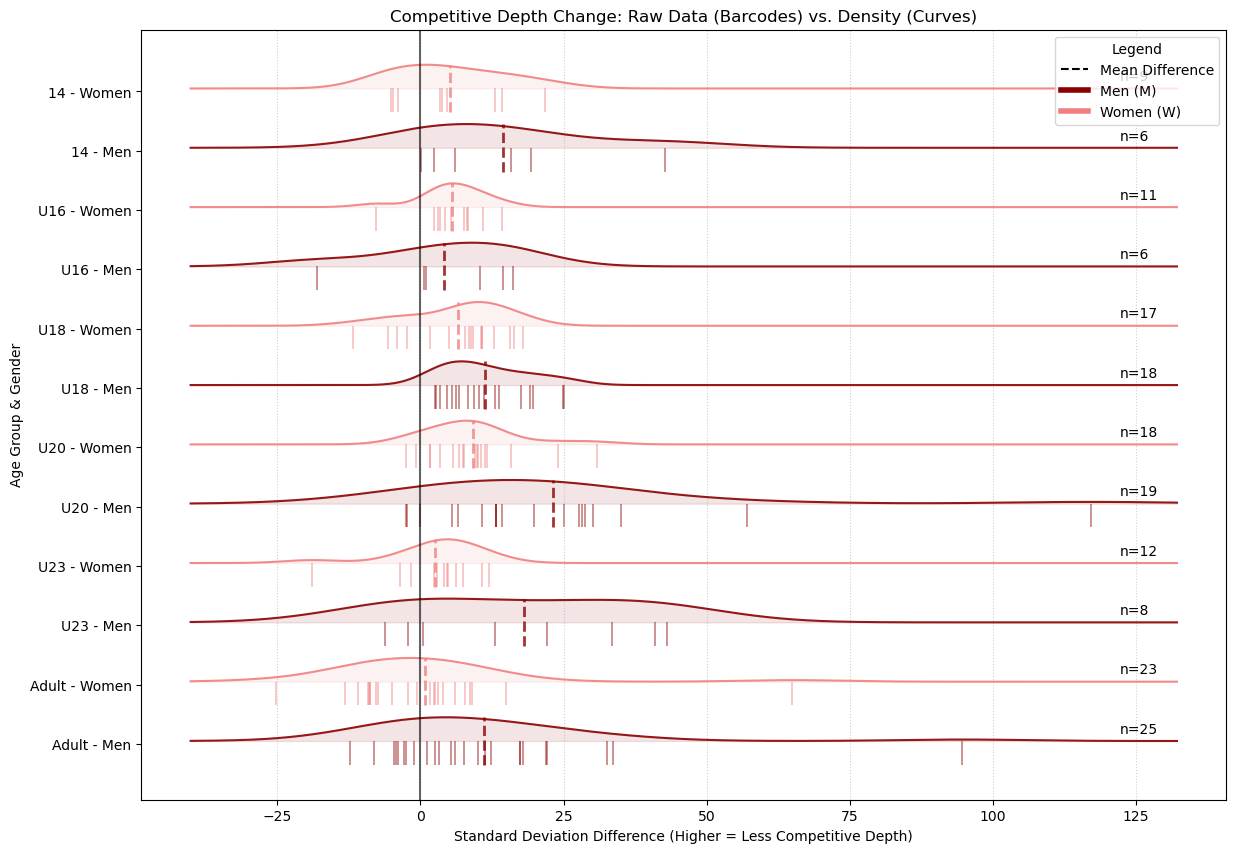

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

# ... (Previous data preparation code for df_diff and y_map remains the same) ...

plt.figure(figsize=(14, 10))

# Define the x-range for the density curves and text placement
x_min, x_max = df_diff['std_diff'].min(), df_diff['std_diff'].max()
x_range = np.linspace(x_min - 15, x_max + 15, 500)

for (age, gender), y in y_map.items():
    subset = df_diff[(df_diff['age'] == age) & (df_diff['gender'] == gender)]['std_diff']
    
    if not subset.empty:
        color = gender_colors[gender]
        group_mean = subset.mean()
        num_subgroups = len(subset)
        
        # 1. Plot the Distribution Curve (KDE) - Positioned above the barcodes
        if len(subset) > 1:
            try:
                kde = gaussian_kde(subset)
                density = kde(x_range)
                density_norm = (density / density.max()) * 0.4  
                
                plt.plot(x_range, density_norm + y + 0.05, color=color, lw=1.5, alpha=0.9)
                plt.fill_between(x_range, y + 0.05, density_norm + y + 0.05, color=color, alpha=0.1)
            except np.linalg.LinAlgError:
                # Handle cases where data variance is zero
                pass

        # 2. Plot the "Barcode" lines (Longer) - Below the curve base
        plt.vlines(x=subset, ymin=y - 0.35, ymax=y + 0.05, 
                   color=color, alpha=0.5, linewidth=1.2, zorder=1)
        
        # 3. Plot the Mean Line (Dashed) - Vertical across the row
        plt.vlines(x=group_mean, ymin=y - 0.35, ymax=y + 0.45, 
                   color=color, linestyle='--', lw=2, alpha=0.8, zorder=3)
        
        # 4. Add the number of subgroups (n=...) on the RIGHT hand side
        # Adjusting the x-coordinate slightly past x_max for padding
        plt.text(x_max + 5, y + 0.25, f"n={num_subgroups}", 
                 va='center', ha='left', fontsize=10, color='black', fontweight='normal')

# Formatting
plt.yticks(range(len(y_labels)), y_labels)

# Reference line at 0
plt.axvline(0, color='black', linestyle='-', alpha=0.6, lw=1.5)

plt.xlabel("Standard Deviation Difference (2021–24 minus 2001–04)")
plt.ylabel("Age Group & Gender")
plt.title("Competitive Depth Change per Subgroup")

# Legend
legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Mean Difference'),
    Line2D([0], [0], color='darkred', lw=4, label='Men (M)'),
    Line2D([0], [0], color='lightcoral', lw=4, label='Women (W)')
]
plt.legend(handles=legend_elements, title="Legend", loc='upper right')

plt.grid(True, axis='x', linestyle=':', alpha=0.6)

# Adjust right margin to make room for the 'n=' labels
plt.subplots_adjust(right=0.9) 

plt.show()

In [25]:
from matplotlib.lines import Line2D


data_std = hp.func_norm_per_group(data=top_raw_all, func=np.mean)

df_std = pd.DataFrame(data_std)

df_std['age'] = df_std['age'].replace({'Maenner': 'Adult', 'Frauen': 'Adult', '16': 'U16', '18': 'U18', '20': 'U20', '14': 'AK14'})

df_start = df_std[df_std['year'].between(2001, 2004)].groupby(['event','gender','age'])['func_value'].mean().reset_index()
df_end   = df_std[df_std['year'].between(2021, 2024)].groupby(['event','gender','age'])['func_value'].mean().reset_index()

df_diff = pd.merge(df_start, df_end, on=['event','gender','age'], suffixes=('_start','_end'))
df_diff['std_diff'] = df_diff['func_value_end'] - df_diff['func_value_start']

unique_ages = sorted([a for a in df_diff['age'].unique() if a != 'Adult'], reverse=True)
age_order = ['Adult'] + unique_ages 
genders = ['M', 'W']
gender_colors = {'M': 'darkred', 'W': 'lightcoral'}

y_map = {}
y_labels = []
y_pos = 0

# Create a separate row for every Age + Gender combination
for age in age_order:
    for gender in genders:
        y_map[(age, gender)] = y_pos
        label = f"{age} - {'Men' if gender == 'M' else 'Women'}"
        y_labels.append(label)
        y_pos += 1



c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:75: FutureWarning: The provided callable <function mean at 0x000001E8301B9080> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)


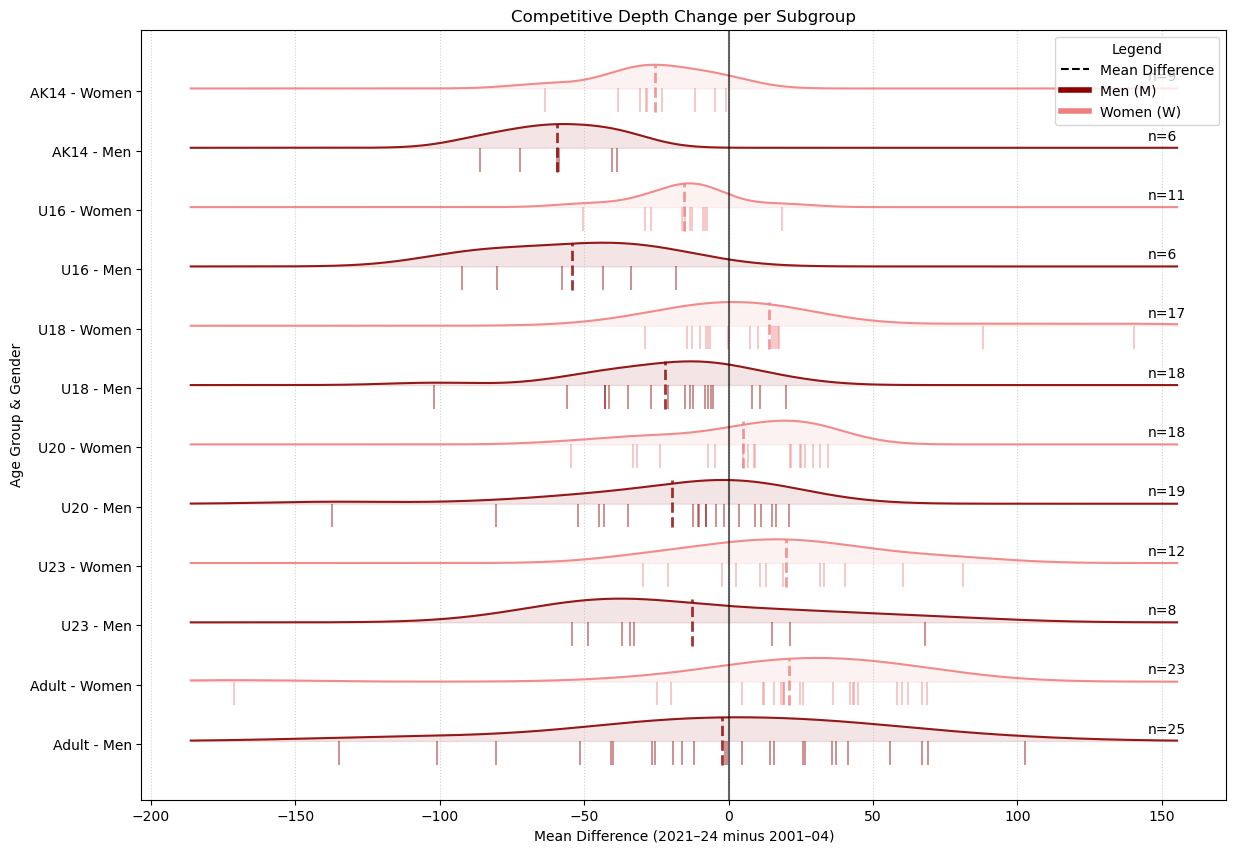

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

# ... (Previous data preparation code for df_diff and y_map remains the same) ...

plt.figure(figsize=(14, 10))

# Define the x-range for the density curves and text placement
x_min, x_max = df_diff['std_diff'].min(), df_diff['std_diff'].max()
x_range = np.linspace(x_min - 15, x_max + 15, 500)

for (age, gender), y in y_map.items():
    subset = df_diff[(df_diff['age'] == age) & (df_diff['gender'] == gender)]['std_diff']
    
    if not subset.empty:
        color = gender_colors[gender]
        group_mean = subset.mean()
        num_subgroups = len(subset)
        
        # 1. Plot the Distribution Curve (KDE) - Positioned above the barcodes
        if len(subset) > 1:
            try:
                kde = gaussian_kde(subset)
                density = kde(x_range)
                density_norm = (density / density.max()) * 0.4  
                
                plt.plot(x_range, density_norm + y + 0.05, color=color, lw=1.5, alpha=0.9)
                plt.fill_between(x_range, y + 0.05, density_norm + y + 0.05, color=color, alpha=0.1)
            except np.linalg.LinAlgError:
                # Handle cases where data variance is zero
                pass

        # 2. Plot the "Barcode" lines (Longer) - Below the curve base
        plt.vlines(x=subset, ymin=y - 0.35, ymax=y + 0.05, 
                   color=color, alpha=0.5, linewidth=1.2, zorder=1)
        
        # 3. Plot the Mean Line (Dashed) - Vertical across the row
        plt.vlines(x=group_mean, ymin=y - 0.35, ymax=y + 0.45, 
                   color=color, linestyle='--', lw=2, alpha=0.8, zorder=3)
        
        # 4. Add the number of subgroups (n=...) on the RIGHT hand side
        # Adjusting the x-coordinate slightly past x_max for padding
        plt.text(x_max + 5, y + 0.25, f"n={num_subgroups}", 
                 va='center', ha='left', fontsize=10, color='black', fontweight='normal')

# Formatting
plt.yticks(range(len(y_labels)), y_labels)

# Reference line at 0
plt.axvline(0, color='black', linestyle='-', alpha=0.6, lw=1.5)

plt.xlabel("Mean Difference (2021–24 minus 2001–04)")
plt.ylabel("Age Group & Gender")
plt.title("Competitive Depth Change per Subgroup")

# Legend
legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Mean Difference'),
    Line2D([0], [0], color='darkred', lw=4, label='Men (M)'),
    Line2D([0], [0], color='lightcoral', lw=4, label='Women (W)')
]
plt.legend(handles=legend_elements, title="Legend", loc='upper right')

plt.grid(True, axis='x', linestyle=':', alpha=0.6)

# Adjust right margin to make room for the 'n=' labels
plt.subplots_adjust(right=0.9) 

plt.show()

c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Lite

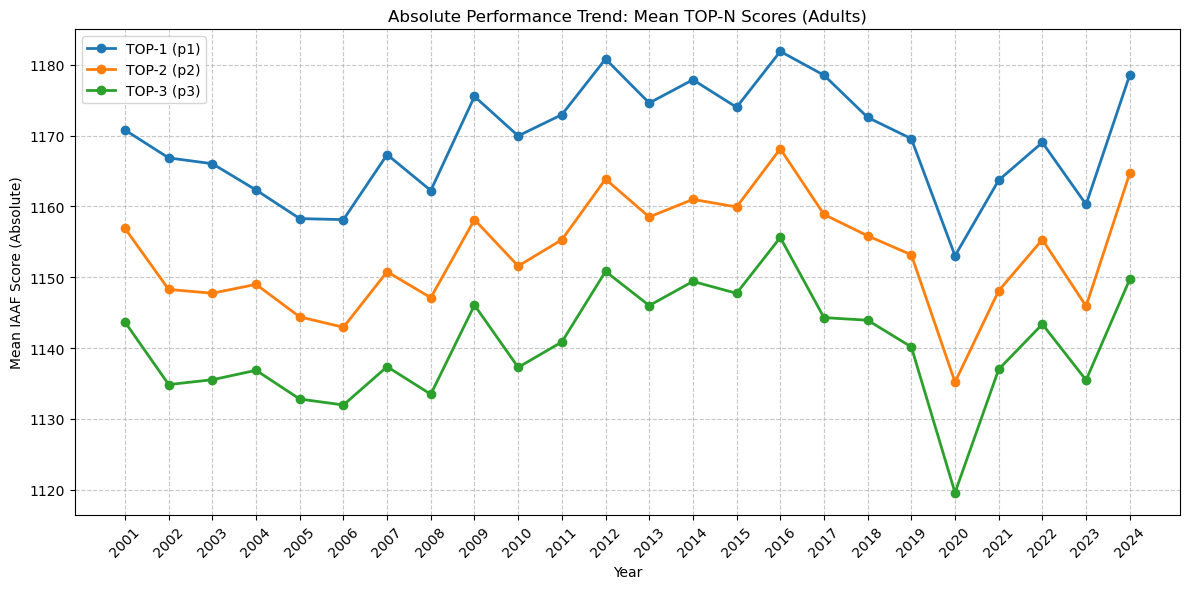

In [44]:
import matplotlib.pyplot as plt 
import pandas as pd 

# List of TOP-N ranks to analyze
top_entries_list = [1, 2, 3] 
stats_list = [] 

# Filter for Adult categories
data_adult = data[(data["altersklasse"] == "Frauen") | (data["altersklasse"] == "Maenner")]

for n in top_entries_list: 
    # Collect top-N entries (using 'n' instead of fixed '40' to get p1, p2, p3)
    top_raw = hp.collect_top_entries(data_adult, num_entries=n) 
    if top_raw.empty: 
        continue 
    
    # Compute absolute mean performance per year
    top_n_mean = top_raw.groupby("jahr")["iaaf_score"].mean().reset_index(name="top_mean") 
    
    # Add a column for the rank label
    top_n_mean["num_entries"] = n
    stats_list.append(top_n_mean) 
    
# Plot ABSOLUTE TOP-N scores
plt.figure(figsize=(12, 6)) 

for stats in stats_list: 
    # Use 'top_mean' for absolute values instead of 'normalized'
    plt.plot(
        stats["jahr"], 
        stats["top_mean"], 
        label=f"TOP-{stats['num_entries'].iloc[0]} (p{stats['num_entries'].iloc[0]})", 
        linewidth=2,
        marker='o'
    ) 

plt.xlabel("Year") 
plt.ylabel("Mean IAAF Score (Absolute)") 
plt.title("Absolute Performance Trend: Mean TOP-N Scores (Adults)") 
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.7) 

# Ensure all years are labeled on the X-axis
all_years = sorted(data["jahr"].unique())
plt.xticks(all_years, rotation=45) 

plt.tight_layout() 
plt.savefig('p1_absolute_trend.png')
plt.show()

c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")


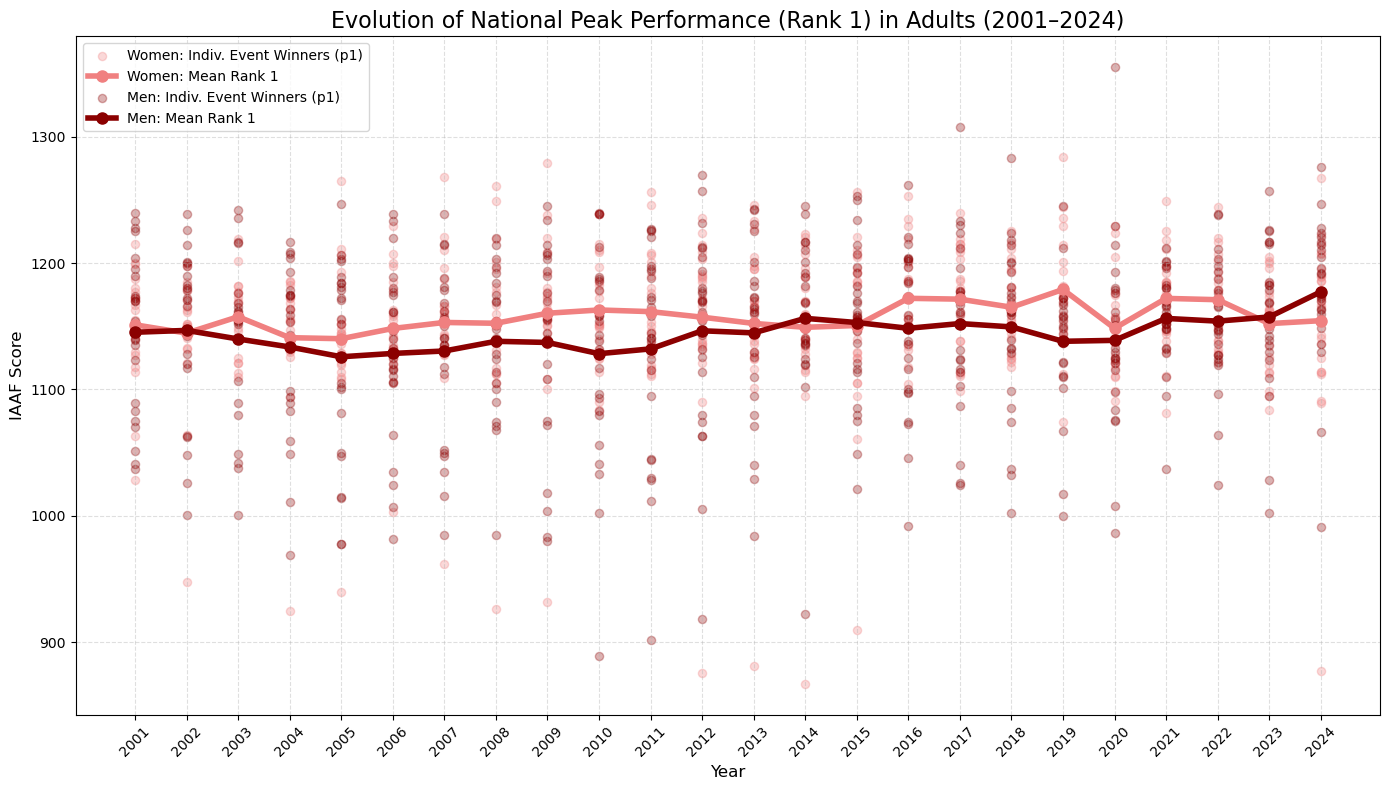

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter for Adult categories (Women/Men)
data_adult = data_ext[data_ext["altersklasse"].isin(["Frauen", "Maenner"])]

# Colors as requested
color_women = "lightcoral" # Light Red
color_men = "darkred"      # Dark Red

# 2. Process Women: Extract p1 (max) for every event each year
data_f = data_adult[data_adult["altersklasse"] == "Frauen"]
top_40_f = hp.collect_top_entries(data_f, num_entries=40)
# Group by year and event to find the single best performance (p1) per discipline
p1_f_events = top_40_f.groupby(["jahr", "disziplin"])["iaaf_score"].max().reset_index()
# Calculate annual mean of all Rank 1s
p1_f_mean = p1_f_events.groupby("jahr")["iaaf_score"].mean()

# 3. Process Men: Extract p1 (max) for every event each year
data_m = data_adult[data_adult["altersklasse"] == "Maenner"]
top_40_m = hp.collect_top_entries(data_m, num_entries=40)
# Group by year and event to find the p1 per discipline
p1_m_events = top_40_m.groupby(["jahr", "disziplin"])["iaaf_score"].max().reset_index()
# Calculate annual mean of all Rank 1s
p1_m_mean = p1_m_events.groupby("jahr")["iaaf_score"].mean()

# 4. Plotting
plt.figure(figsize=(14, 8))

# --- Women ---
# Individual event winners (p1)
plt.scatter(p1_f_events["jahr"], p1_f_events["iaaf_score"], 
            color=color_women, alpha=0.3, s=35, label="Women: Indiv. Event Winners (p1)")
# Mean trend line
plt.plot(p1_f_mean.index, p1_f_mean.values, 
         color=color_women, linewidth=4, marker='o', markersize=8, label="Women: Mean Rank 1")

# --- Men ---
# Individual event winners (p1)
plt.scatter(p1_m_events["jahr"], p1_m_events["iaaf_score"], 
            color=color_men, alpha=0.3, s=35, label="Men: Indiv. Event Winners (p1)")
# Mean trend line
plt.plot(p1_m_mean.index, p1_m_mean.values, 
         color=color_men, linewidth=4, marker='o', markersize=8, label="Men: Mean Rank 1")

# 5. Formatting
plt.title("Evolution of National Peak Performance (Rank 1) in Adults (2001–2024)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("IAAF Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(sorted(data_adult["jahr"].unique()), rotation=45)
plt.legend(frameon=True, facecolor='white', loc='upper left')

plt.tight_layout()
plt.show()

In [56]:
# 1. Combine event data and label by gender
p1_f_events["gender"] = "Women"
p1_m_events["gender"] = "Men"
all_p1_data = pd.concat([p1_f_events, p1_m_events])

# 2. Pivot to compare 2001 vs 2024 for each discipline AND gender
# Using 'disziplin' as requested in your previous code
pivot_gender = all_p1_data[all_p1_data["jahr"].isin([2001, 2024])].pivot_table(
    index=["disziplin", "gender"], 
    columns="jahr", 
    values="iaaf_score"
).reset_index()

# 3. Calculate absolute and percentage changes
pivot_gender["abs_diff"] = pivot_gender[2024] - pivot_gender[2001]
pivot_gender["pct_change"] = (pivot_gender["abs_diff"] / pivot_gender[2001]) * 100

# 4. Display the results (Sorting by Men/Women for clear comparison)
pivot_gender = pivot_gender.sort_values(by=["gender", "pct_change"], ascending=[True, False])

print("Performance Change by Gender (2001 vs 2024):")
print(pivot_gender[["gender", "disziplin", 2001, 2024, "pct_change"]])

Performance Change by Gender (2001 vs 2024):
jahr gender         disziplin    2001    2024  pct_change
41      Men          Marathon  1051.0  1224.0   16.460514
2       Men             10 km  1041.0  1163.0   11.719500
33      Men      Halbmarathon  1037.0  1149.0   10.800386
50      Men         Zehnkampf  1174.0  1276.0    8.688245
0       Men          10 000 m  1070.0  1160.0    8.411215
25      Men            5000 m  1089.0  1172.0    7.621671
6       Men             100 m  1135.0  1210.0    6.607930
11      Men            1500 m  1139.0  1214.0    6.584723
13      Men             200 m  1123.0  1196.0    6.500445
21      Men     400 m Huerden  1149.0  1221.0    6.266319
31      Men        Dreisprung  1154.0  1205.0    4.419411
15      Men            3000 m  1144.0  1177.0    2.884615
17      Men  3000 m Hindernis  1170.0  1192.0    1.880342
44      Men         Speerwurf  1228.0  1247.0    1.547231
10      Men     110 m Huerden  1172.0  1174.0    0.170648
35      Men        Hammerwu

In [57]:
# 1. Process Women: Extract p40 (min of top 40) for every discipline
p40_f_events = top_40_f.groupby(["jahr", "disziplin"])["iaaf_score"].min().reset_index()
p40_f_events["gender"] = "Women"

# 2. Process Men: Extract p40 (min of top 40) for every discipline
p40_m_events = top_40_m.groupby(["jahr", "disziplin"])["iaaf_score"].min().reset_index()
p40_m_events["gender"] = "Men"

# 3. Combine and Pivot for 2001 vs 2024 comparison
all_p40_data = pd.concat([p40_f_events, p40_m_events])
pivot_p40 = all_p40_data[all_p40_data["jahr"].isin([2001, 2024])].pivot_table(
    index=["disziplin", "gender"], 
    columns="jahr", 
    values="iaaf_score"
).reset_index()

# 4. Calculate absolute and percentage changes
pivot_p40["abs_diff"] = pivot_p40[2024] - pivot_p40[2001]
pivot_p40["pct_change"] = (pivot_p40["abs_diff"] / pivot_p40[2001]) * 100

# 5. Display sorted by change
pivot_p40 = pivot_p40.sort_values(by=["gender", "pct_change"], ascending=[True, False])

print("National Elite 'Floor' Evolution (Rank 40: 2001 vs 2024):")
print(pivot_p40[["gender", "disziplin", 2001, 2024, "pct_change"]])

National Elite 'Floor' Evolution (Rank 40: 2001 vs 2024):
jahr gender         disziplin    2001    2024  pct_change
41      Men          Marathon   798.0   887.0   11.152882
33      Men      Halbmarathon   870.0   927.0    6.551724
6       Men             100 m   965.0  1021.0    5.803109
25      Men            5000 m   872.0   916.0    5.045872
11      Men            1500 m   968.0  1008.0    4.132231
13      Men             200 m   960.0   994.0    3.541667
0       Men          10 000 m   833.0   862.0    3.481393
2       Men             10 km   906.0   932.0    2.869757
19      Men             400 m   971.0   989.0    1.853759
15      Men            3000 m   887.0   885.0   -0.225479
21      Men     400 m Huerden   928.0   924.0   -0.431034
27      Men             800 m   987.0   980.0   -0.709220
46      Men    Stabhochsprung   967.0   940.0   -2.792141
29      Men        Diskuswurf   864.0   833.0   -3.587963
44      Men         Speerwurf   893.0   856.0   -4.143337
48      Men   

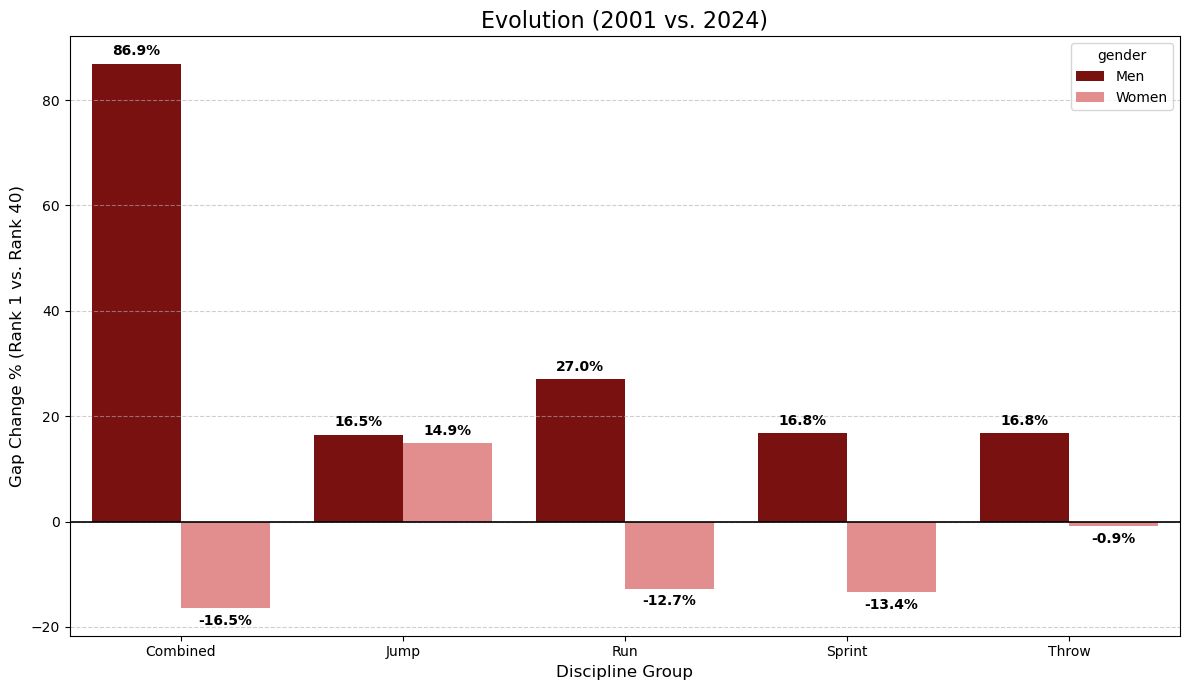

  gender  category  gap_change_pct
0    Men  Combined       86.936937
1    Men      Jump       16.478116
2    Men       Run       27.006792
3    Men    Sprint       16.758742
4    Men     Throw       16.802465
5  Women  Combined      -16.501650
6  Women      Jump       14.895820
7  Women       Run      -12.745410
8  Women    Sprint      -13.406020
9  Women     Throw       -0.879018


In [ ]:

# 1. Define Discipline Groups
run_disciplines = ['800 m', '1500 m', '3000 m', '5000 m', '10 000 m', 'Marathon', '10 km', 'Halbmarathon', '3000 m Hindernis', '1000 m']
sprint_disciplines = ['100 m', '200 m', '400 m', '400 m Huerden', '110 m Huerden', '100 m Huerden']
throw_disciplines = ['Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf']
jump_disciplines = ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']
combined_disciplines = ['Zehnkampf', 'Siebenkampf']

# 2. Prepare Data (Merge p1 and p40 DataFrames)
# Assuming 'pivot_gender' is your Rank 1 table and 'pivot_p40' is your Rank 40 table
density_df = pd.merge(
    pivot_gender[['gender', 'disziplin', 2001, 2024]].rename(columns={2001: 'p1_2001', 2024: 'p1_2024'}),
    pivot_p40[['gender', 'disziplin', 2001, 2024]].rename(columns={2001: 'p40_2001', 2024: 'p40_2024'}),
    on=['gender', 'disziplin']
)

# 3. Calculate Performance Gaps
density_df['gap_2001'] = density_df['p1_2001'] - density_df['p40_2001']
density_df['gap_2024'] = density_df['p1_2024'] - density_df['p40_2024']

# 4. Calculate Talent Density Index (Gap Change %)
# Positive % = Gap Widening (Bad/Hollowing Out)
# Negative % = Gap Narrowing (Good/Increasing Depth)
density_df['gap_change_pct'] = ((density_df['gap_2024'] - density_df['gap_2001']) / density_df['gap_2001']) * 100

# 5. Assign Categories
def categorize_discipline(d):
    if d in run_disciplines: return 'Run'
    if d in sprint_disciplines: return 'Sprint'
    if d in throw_disciplines: return 'Throw'
    if d in jump_disciplines: return 'Jump'
    if d in combined_disciplines: return 'Combined'

density_df['category'] = density_df['disziplin'].apply(categorize_discipline)

# 6. Filter Outliers (e.g., 100km which has extreme low data density)
density_filtered = density_df[density_df['disziplin'] != '100 km']

# 7. Aggregate Summary
summary = density_filtered.groupby(['gender', 'category'])['gap_change_pct'].mean().reset_index()

# 8. Visualization
plt.figure(figsize=(12, 7))
sns.barplot(data=summary, x='category', y='gap_change_pct', hue='gender', 
            palette={'Men': 'darkred', 'Women': 'lightcoral'})

plt.axhline(0, color='black', linewidth=1.2, linestyle='-')
plt.title("Evolution (2001 vs. 2024)", fontsize=16)
plt.ylabel("Gap Change % (Rank 1 vs. Rank 40)", fontsize=12)
plt.xlabel("Discipline Group", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adding Data Labels
for p in plt.gca().patches:
    if p.get_height() != 0:
        plt.gca().annotate(f'{p.get_height():.1f}%', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='center', 
                           xytext=(0, 9 if p.get_height() > 0 else -9), 
                           textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(summary)

#NOTE: Siebenkampf and zehnkampf cannot be the same in sanity check as the other disciplines because tthey are seperate for men and women. Also for 100m Hureden and 110m Huerden.